# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test3 evolutor

Notebook equivalent of `tests/4_earth/test3_evolutor.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test3_evolutor"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test3_evolutor.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test3_evolutor


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_import_earth_evolutor`

**What is checked:** Import earth evolutor behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: earth_evolutor must be callable.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_import_earth_evolutor)


Running test_import_earth_evolutor ...

Imported public earth evolutor:
earth_evolutor : <function earth_evolutor at 0x00000246940BCDC0>
------------------------------------------------------------------------------------------
PASSED: test_import_earth_evolutor


## Test: `test_broadcast_energy_and_eta_helper`

**What is checked:** Broadcast energy and eta helper behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Energy vector and eta vector must broadcast to a grid; Eta vector and energy vector must broadcast to a grid; Broadcast helper must keep the energy tensor device; Broadcast helper must keep the energy tensor dtype; and additional consistency checks.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_broadcast_energy_and_eta_helper)


Running test_broadcast_energy_and_eta_helper ...

Broadcasted energy and eta:
E_b shape   : (3, 2)
eta_b shape : (3, 2)
device      : cpu
real dtype  : torch.float64
complex dtype: torch.complex128
E_b:
tensor([[5.0000000000e+02, 5.0000000000e+02],
        [1.0000000000e+03, 1.0000000000e+03],
        [5.0000000000e+03, 5.0000000000e+03]], dtype=torch.float64)
eta_b:
tensor([[2.0000000000e-01, 8.0000000000e-01],
        [2.0000000000e-01, 8.0000000000e-01],
        [2.0000000000e-01, 8.0000000000e-01]], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_broadcast_energy_and_eta_helper


## Test: `test_above_horizon_is_identity_at_surface`

**What is checked:** Above horizon is identity at surface behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_above_horizon_is_identity_at_surface)


Running test_above_horizon_is_identity_at_surface ...

Above-horizon surface output:
eta: tensor([1.5707963268e+00, 2.0000000000e+00, 3.0000000000e+00], dtype=torch.float64)
U shape: (3, 3, 3)
U[0]:
tensor([[1.0000000000e+00+0.j, 0.0000000000e+00+0.j, 0.0000000000e+00+0.j],
        [0.0000000000e+00+0.j, 1.0000000000e+00+0.j, 0.0000000000e+00+0.j],
        [0.0000000000e+00+0.j, 0.0000000000e+00+0.j, 1.0000000000e+00+0.j]], dtype=torch.complex128)
Checking: Surface above-horizon trajectories return identity
  actual shape  : (3, 3, 3)
  expected shape: (3, 3, 3)
  max abs diff  : 0.000000e+00
  atol / rtol   : 1.0e-12 / 1.0e-12
------------------------------------------------------------------------------------------
PASSED: test_above_horizon_is_identity_at_surface


## Test: `test_case_a_scalar_evolutor_is_finite_and_unitary`

**What is checked:** Case a scalar evolutor is finite and unitary behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Scalar Case-A output must have shape (3, 3); Case-A real part must be finite; Case-A imaginary part must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [7]:
run_notebook_test(TEST_MODULE.test_case_a_scalar_evolutor_is_finite_and_unitary)


Running test_case_a_scalar_evolutor_is_finite_and_unitary ...

Case-A scalar evolutor:
U shape: (3, 3)
U:
tensor([[-8.6045080478e-01+2.1875094303e-01j, -5.9094777484e-02-9.0489001810e-02j, 2.0715898800e-01-3.9645572135e-01j],
        [-2.4142555230e-02+3.8186697623e-01j, 5.2573776271e-01-4.4953716510e-01j, 3.7573257078e-01+4.8366923285e-01j],
        [2.4249061766e-01+8.1027694745e-02j, 4.4583375506e-01+5.5773466158e-01j, 5.0581120213e-01-4.1103789478e-01j]], dtype=torch.complex128)
Checking: Case-A scalar output is unitary
  U shape             : (3, 3)
  max unitarity error : 6.101592e-16
------------------------------------------------------------------------------------------
PASSED: test_case_a_scalar_evolutor_is_finite_and_unitary


## Test: `test_case_b_underground_evolutor_is_finite_and_unitary`

**What is checked:** Case b underground evolutor is finite and unitary behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Scalar Case-B output must have shape (3, 3); Case-B real part must be finite; Case-B imaginary part must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [8]:
run_notebook_test(TEST_MODULE.test_case_b_underground_evolutor_is_finite_and_unitary)


Running test_case_b_underground_evolutor_is_finite_and_unitary ...

Case-B underground evolutor:
U shape: (3, 3)
max |U|: 0.99999987064515
distance from identity: 0.003596430796211339
Checking: Case-B scalar output is unitary
  U shape             : (3, 3)
  max unitarity error : 2.220446e-16
------------------------------------------------------------------------------------------
PASSED: test_case_b_underground_evolutor_is_finite_and_unitary


## Test: `test_energy_eta_grid_output_shape_and_identity_region`

**What is checked:** Energy eta grid output shape and identity region behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Energy vector and eta vector output must have shape (NE, Neta, 3, 3).

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [9]:
run_notebook_test(TEST_MODULE.test_energy_eta_grid_output_shape_and_identity_region)


Running test_energy_eta_grid_output_shape_and_identity_region ...

Energy-eta grid evolutor:
E shape  : (3,)
eta shape: (2,)
U shape  : (3, 2, 3, 3)
unitarity errors:
tensor([[3.3306690739e-16, 0.0000000000e+00],
        [2.2204460493e-16, 0.0000000000e+00],
        [2.2204460493e-16, 0.0000000000e+00]], dtype=torch.float64)
Checking: Energy-eta grid output is unitary
  U shape             : (3, 2, 3, 3)
  max unitarity error : 3.330669e-16
Checking: Above-horizon eta column is identity
  actual shape  : (3, 3, 3)
  expected shape: (3, 3, 3)
  max abs diff  : 0.000000e+00
  atol / rtol   : 1.0e-12 / 1.0e-12
------------------------------------------------------------------------------------------
PASSED: test_energy_eta_grid_output_shape_and_identity_region


## Test: `test_antineutrino_path_runs_and_is_unitary`

**What is checked:** Antineutrino path runs and is unitary behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Antineutrino batch output must have shape (2, 3, 3); Neutrino and antineutrino paths should not be exactly identical for these inputs.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [10]:
run_notebook_test(TEST_MODULE.test_antineutrino_path_runs_and_is_unitary)


Running test_antineutrino_path_runs_and_is_unitary ...

Neutrino vs antineutrino:
U_nu shape     : (2, 3, 3)
U_antinu shape : (2, 3, 3)
max |difference|: 1.725914e+00
Checking: Antineutrino output is unitary
  U shape             : (2, 3, 3)
  max unitarity error : 1.554312e-15
------------------------------------------------------------------------------------------
PASSED: test_antineutrino_path_runs_and_is_unitary


## Test: `test_invalid_eta_raises_value_error`

**What is checked:** Invalid eta raises value error behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [11]:
run_notebook_test(TEST_MODULE.test_invalid_eta_raises_value_error)


Running test_invalid_eta_raises_value_error ...

Invalid eta test:
eta = -0.01 should raise ValueError
------------------------------------------------------------------------------------------
PASSED: test_invalid_eta_raises_value_error


## Plot: `plot_unitarity_error_vs_eta()`

**What is checked:** Unitarity error vs eta behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_evolutor_unitarity_vs_eta.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_unitarity_error_vs_eta()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_evolutor_unitarity_vs_eta.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_unitarity_error_vs_eta() ...
Saved plot: V:\output\test\earth\test3_evolutor\plot_unitarity_error_vs_eta_figure_001.png


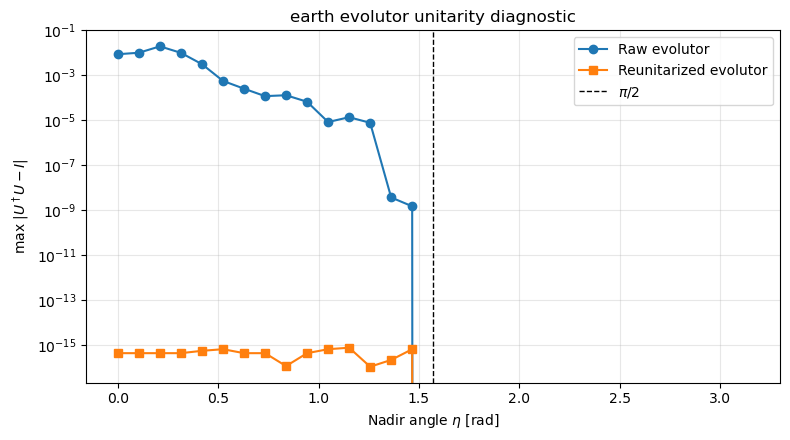

PASSED: plot_unitarity_error_vs_eta()


In [12]:
run_notebook_call('plot_unitarity_error_vs_eta()', lambda: TEST_MODULE.plot_unitarity_error_vs_eta())


## Plot: `plot_distance_from_identity_map()`

**What is checked:** Distance from identity map behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_evolutor_distance_from_identity.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_distance_from_identity_map()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_evolutor_distance_from_identity.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_distance_from_identity_map() ...
Saved plot: V:\output\test\earth\test3_evolutor\plot_distance_from_identity_map_figure_001.png


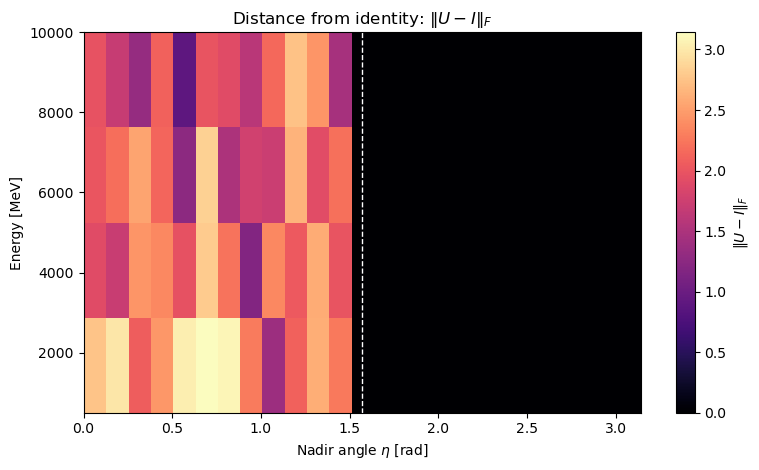

PASSED: plot_distance_from_identity_map()


In [13]:
run_notebook_call('plot_distance_from_identity_map()', lambda: TEST_MODULE.plot_distance_from_identity_map())


## Plot: `plot_matrix_magnitude_examples()`

**What is checked:** Matrix magnitude examples behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_evolutor_matrix_magnitudes.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_matrix_magnitude_examples()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_evolutor_matrix_magnitudes.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_matrix_magnitude_examples() ...
Saved plot: V:\output\test\earth\test3_evolutor\plot_matrix_magnitude_examples_figure_001.png


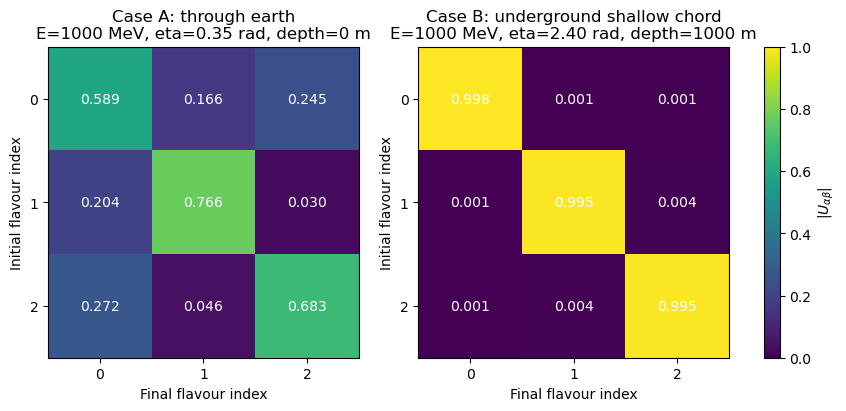

PASSED: plot_matrix_magnitude_examples()


In [14]:
run_notebook_call('plot_matrix_magnitude_examples()', lambda: TEST_MODULE.plot_matrix_magnitude_examples())
